# 2. Visualize the Pipeline

This notebook demonstrates how to visualize the LC-MS pipeline schema using DataJoint's diagram notation.

In [ ]:
# DataJoint reads datajoint.json automatically
import datajoint as dj
from lcms_demo.pipeline import subject, session, scan

## Full Pipeline Diagram

DataJoint's `dj.Diagram` creates entity-relationship diagrams showing table relationships.

**Legend:**
- **Green**: Manual tables (data entered manually)
- **Green with dot**: Lookup tables (reference data)
- **Blue**: Imported tables (data from external sources)
- **Red**: Computed tables (derived data)
- **Solid lines**: Primary key dependencies
- **Dashed lines**: Non-primary foreign keys

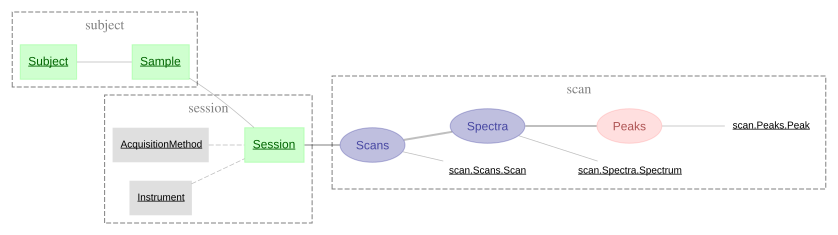

In [3]:
# Complete pipeline diagram
dj.Diagram(subject.schema) + dj.Diagram(session.schema) + dj.Diagram(scan.schema)

## Individual Schema Diagrams

### Subject Schema

Contains experimental subjects and biological samples.

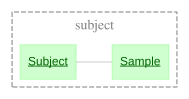

In [4]:
dj.Diagram(subject.schema)

### Session Schema

Contains instruments, acquisition methods, and LC-MS sessions.

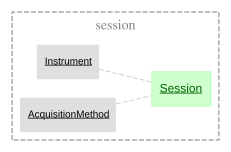

In [5]:
dj.Diagram(session.schema)

### Scan Schema

Contains scan data, spectra, and detected peaks.

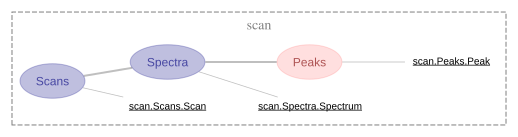

In [6]:
dj.Diagram(scan.schema)

## Table Definitions

View the definition of individual tables using `describe()`.

In [7]:
subject.Subject.describe()

'# Experimental subject or sample source\nsubject_id           : varchar(32)                  \n---\nsubject_description="\'\'::character varying" : varchar(256)                 \n'

In [8]:
subject.Sample.describe()

'# Biological or chemical sample\n-> subject.Subject\nsample_id            : varchar(32)                  \n---\nsample_type          : varchar(64)                  # e.g., plasma, liver, urine\ncollection_datetime=null : datetime                     \nsample_description="\'\'::character varying" : varchar(256)                 \n'

In [9]:
session.Session.describe()

'# LC-MS acquisition session\n-> subject.Sample\nsession_idx          : int32                        # session index within sample\n---\nsession_datetime     : datetime                     \n-> session.Instrument\n-> session.AcquisitionMethod\nraw_data_path        : varchar(512)                 \nsession_notes="\'\'::character varying" : varchar(1024)                \n'

In [10]:
scan.Scans.describe()

'# All scans for a session\n-> session.Session\n---\nn_scans              : int32                        # total number of scans\n'

In [11]:
scan.Spectra.describe()

'# All spectra for a session\n-> scan.Scans\n'

In [12]:
scan.Peaks.describe()

'# All detected peaks for a session\n-> scan.Spectra\n---\ntotal_peaks          : int32                        # total peaks across all scans\n'